# Bangkok District — NDT7 Fixed Broadband Speed Analysis

Province-level analysis cuts too coarse for Bangkok.  
This notebook aggregates NDT7 (M-Lab) fixed broadband measurements to **50 เขต (district)** level.

**District boundary source:** GADM 4.1 Thailand Level 2 (`bangkok_districts.geojson`)  
**Speed data:** NDT7 (M-Lab) — fixed broadband (latest available quarter)  
**Methodology:** mirrors `bkk_district_eda.ipynb` (Ookla) — results are directly comparable

In [24]:
import geopandas as gpd
import pandas as pd
import dask.dataframe as dd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.font_manager as fm
import numpy as np
import os, warnings
warnings.filterwarnings('ignore')

_thai_font_set = False
for _fp in [
    os.path.join(os.environ.get('LOCALAPPDATA', ''),
                 r'Microsoft\Windows\Fonts\THSarabunNew.ttf'),
    r'C:\Windows\Fonts\THSarabunNew.ttf',
    os.path.expanduser('~/.local/share/fonts/Sarabun/Sarabun-Regular.ttf'),
]:
    if os.path.exists(_fp):
        try:
            fm.fontManager.addfont(_fp)
            _prop = fm.FontProperties(fname=_fp)
            plt.rcParams['font.family'] = _prop.get_name()
            _thai_font_set = True
            print(f'Thai font loaded: {_prop.get_name()}')
            break
        except Exception:
            pass
if not _thai_font_set:
    plt.rcParams['font.family'] = 'Tahoma'
    print('Fallback font: Tahoma')
plt.rcParams['axes.unicode_minus'] = False

Thai font loaded: TH Sarabun New


### Config

In [25]:
BKK_DISTRICTS_GEOJSON = 'data/bangkok_districts.geojson'
MLAB_DIR              = 'mlab_results'
CLIENT_PKT            = 'data/client_complete.parquet'
OUTPUT_DIR            = 'outputs/ndt7'

QUARTER = '2024-Q4'  # change to use different quarter, or 'all'

ZOOM           = 16
N_TILES        = 2 ** ZOOM
MIN_TILE_TESTS = 3
VALID_ISP_BB   = {'AIS', 'TRUE', '3BB', 'CAT', 'NT', 'Cableconnect', 'Sophon'}

METRIC_MBPS = 'avg_d_mbps'

### Load Bangkok District Boundaries

In [26]:
bkk_gdf = gpd.read_file(BKK_DISTRICTS_GEOJSON).to_crs(4326)
state_bounds = bkk_gdf.total_bounds  # [min_lon, min_lat, max_lon, max_lat]

print(f'Districts loaded: {len(bkk_gdf)}')
print(f'Bangkok bbox: lon {state_bounds[0]:.4f}\u2013{state_bounds[2]:.4f}, lat {state_bounds[1]:.4f}\u2013{state_bounds[3]:.4f}')
bkk_gdf.head()

Districts loaded: 50
Bangkok bbox: lon 100.3200–100.9391, lat 13.4925–13.9543


,gid,name_en,name_th,geometry
0,THA.3.1_1,BangBon,บางบอน,"MULTIPOLYGON (((100.3823 13.6759, 100.3856 13...."
1,THA.3.2_1,BangKapi,บางกะปิ,"MULTIPOLYGON (((100.623 13.8205, 100.6243 13.8..."
2,THA.3.3_1,BangKhae,บางแค,"MULTIPOLYGON (((100.4262 13.6905, 100.3917 13...."
3,THA.3.4_1,BangKhen,บางเขน,"MULTIPOLYGON (((100.6481 13.849, 100.6406 13.8..."
4,THA.3.5_1,BangKhoLaem,บางคอแหลม,"MULTIPOLYGON (((100.497 13.7085, 100.5067 13.7..."


### Load NDT7 Tiles (Bangkok Bbox Only)

In [ ]:
client_df = pd.read_parquet(CLIENT_PKT)
client_df = client_df.drop(
    columns=[c for c in ['mobile'] if c in client_df.columns]
)

result_ddf = dd.read_parquet(MLAB_DIR)
result_ddf = result_ddf.dropna(
    subset=['id', 'date', 'city', 'mean_throughput_mbps', 'type']
)
result_ddf['city'] = result_ddf['city'].str.strip().str.title()

result_ddf = result_ddf[
    (result_ddf['type']                == 'download') &
    (result_ddf['mean_throughput_mbps'] >  0) &
    (result_ddf['longitude'] >= float(state_bounds[0])) &
    (result_ddf['longitude'] <= float(state_bounds[2])) &
    (result_ddf['latitude']  >= float(state_bounds[1])) &
    (result_ddf['latitude']  <= float(state_bounds[3]))
]

df_bkk = result_ddf.compute()

df_bkk = df_bkk.merge(client_df, on='client_ip', how='left')

# Keep broadband ISPs only
df_bkk = df_bkk[
    (df_bkk['network_type'] == 'broadband') &
    df_bkk['description'].isin(VALID_ISP_BB)
].copy()

df_bkk['date'] = pd.to_datetime(df_bkk['date'])
df_bkk['year_q'] = (
    df_bkk['date'].dt.to_period('Q').astype(str)
    .str.replace(r'(\d{4})Q(\d)', r'\1-Q\2', regex=True)
)
if QUARTER != 'all':
    df_bkk = df_bkk[df_bkk['year_q'] == QUARTER].copy()
    QUARTER_LABEL = QUARTER
else:
    QUARTER_LABEL = f"{df_bkk['year_q'].min()}\u2013{df_bkk['year_q'].max()}"

print(f'Broadband NDT7 records in Bangkok: {len(df_bkk):,}')
print(f'Quarters covered: {QUARTER_LABEL}')
print(f'Tiles in Bangkok bbox: {df_bkk.shape[0]:,}')
df_bkk.head()

Broadband NDT7 records in Bangkok: 878,428
Quarters covered: 2024-Q4
Tiles in Bangkok bbox: 878,428


,id,date,test_time,mean_throughput_mbps,min_rtt,loss_rate,server_ip,client_ip,duration,city,latitude,longitude,type,isp,category,description,network_type,year_q
2,ndt-vzs2c_1727329882_000000000039E435,2024-10-30,2024-10-30 12:19:09.353017,596.245003,25.573,0.000000,2405:2000:301::88,2001:fb1:ef:3bcb:583c:3a6c:3106:fca6,0,Mueang Samut Prakan,13.5981,100.5925,download,True Internet Corporation CO. Ltd.,Consumer Broadband,TRUE,broadband,2024-Q4
3,ndt-nsck2_1727329882_000000000009F8BA,2024-10-02,2024-10-02 04:34:43.678786,2.475818,31.657,0.002985,2405:2000:301::88,2001:fb1:81:49c9:a8cb:3d7a:8140:a106,0,Bang Phli,13.6000,100.7164,download,True Internet Corporation CO. Ltd.,Consumer Broadband,TRUE,broadband,2024-Q4
5,ndt-28j6n_1727290164_0000000000398B1F,2024-11-15,2024-11-15 11:50:57.059002,0.087949,354.752,0.000000,2402:4480:400::101,2001:fb1:82:5157:ecad:ce66:b739:edc6,0,Bang Phli,13.6000,100.7164,download,True Internet Corporation CO. Ltd.,Consumer Broadband,TRUE,broadband,2024-Q4
7,ndt-xhwt9_1727290164_000000000028434A,2024-10-31,2024-10-31 02:55:26.175651,0.154780,210.723,0.000000,154.18.169.101,182.53.61.228,0,Bangkok,13.6671,100.5775,download,TOT Public Company Limited,Consumer Broadband,NT,broadband,2024-Q4
18,ndt-virtual-hd6vl_1727195719_0000000000309A51,2024-10-21,2024-10-21 13:06:18.278243,36.310848,30.147,0.000000,34.87.82.101,171.101.227.189,0,Bangkok,13.6984,100.4638,download,True Internet Corporation CO. Ltd.,Consumer Broadband,TRUE,broadband,2024-Q4


### Create GeoDataFrame from Tile Centroids

In [ ]:
lat_rad    = np.radians(df_bkk['latitude'].clip(-85.05112878, 85.05112878))
mercator_y = np.log(np.tan(lat_rad) + 1.0 / np.cos(lat_rad))

df_bkk['tile_x'] = ((df_bkk['longitude'] + 180) / 360 * N_TILES).astype(int).clip(0, N_TILES - 1)
df_bkk['tile_y'] = ((1 - mercator_y / np.pi) / 2 * N_TILES).astype(int).clip(0, N_TILES - 1)
df_bkk['tile_id'] = df_bkk['tile_x'].astype(str) + '_' + df_bkk['tile_y'].astype(str)

tile_agg = (
    df_bkk.groupby(['tile_id', 'tile_x', 'tile_y'])
    .agg(
        tile_mean=('mean_throughput_mbps', 'mean'),
        tests=('mean_throughput_mbps', 'count'),
    )
    .reset_index()
)
tile_agg = tile_agg[tile_agg['tests'] >= MIN_TILE_TESTS].copy()

lon_c = (tile_agg['tile_x'] + 0.5) / N_TILES * 360 - 180
lat_c = np.degrees(
    np.arctan(np.sinh(np.pi * (1 - 2 * (tile_agg['tile_y'] + 0.5) / N_TILES)))
)

tiles_gdf = gpd.GeoDataFrame(
    tile_agg,
    geometry=gpd.points_from_xy(lon_c, lat_c),
    crs='EPSG:4326',
).drop(columns=['tile_x', 'tile_y'])

tiles_gdf.dropna(subset=['tile_mean'], inplace=True)
print(f'Valid tiles after dropna: {len(tiles_gdf):,}')

Valid tiles after dropna: 50


### Spatial Join — Tiles → Districts

In [29]:
joined = gpd.sjoin(
    tiles_gdf,
    bkk_gdf[['name_en', 'name_th', 'geometry']],
    how='inner',
    predicate='intersects',
)[['name_en', 'name_th', 'tests', 'tile_mean']]

print(f'Tiles matched to districts: {len(joined):,}')
print(f'Districts covered: {joined["name_en"].nunique()}/50')

Tiles matched to districts: 31
Districts covered: 24/50


### Aggregate: Weighted Average per District

In [30]:
district_stats = (
    joined.groupby(['name_en', 'name_th'])
    .apply(
        lambda x: pd.Series({
            METRIC_MBPS:   np.average(x['tile_mean'], weights=x['tests']),
            'total_tests': x['tests'].sum(),
            'n_tiles':     len(x),
        }),
        include_groups=False,
    )
    .reset_index()
    .sort_values(METRIC_MBPS, ascending=False)
    .reset_index(drop=True)
)

district_stats['rank'] = district_stats[METRIC_MBPS].rank(ascending=False).astype(int)
print(f'Districts aggregated: {len(district_stats)}')
district_stats.head(10)

Districts aggregated: 24


,name_en,name_th,avg_d_mbps,total_tests,n_tiles,rank
0,Prakanong,พระโขนง,206.446619,452.0,1.0,1
1,RatBurana,ราษฎร์บูรณะ,166.817602,8721.0,2.0,2
2,BangKhen,บางเขน,163.208454,22422.0,2.0,3
3,MinBuri,มีนบุรี,163.164747,11909.0,2.0,4
4,ThonBuri,ธนบุรี,152.807893,62604.0,1.0,5
5,BangKapi,บางกะปิ,142.133099,12537.0,1.0,6
6,KhanNaYao,คันนายาว,131.193668,3009.0,1.0,7
7,Ratchathewi,ราชเทวี,129.053994,61208.0,1.0,8
8,SaphanSung,สะพานสูง,123.637842,853.0,1.0,9
9,Dusit,ดุสิต,120.765677,94592.0,2.0,10


### Top 10 / Bottom 10

In [31]:
top10    = district_stats.head(10)[['rank','name_en','name_th', METRIC_MBPS, 'total_tests']]
bottom10 = district_stats.tail(10)[['rank','name_en','name_th', METRIC_MBPS, 'total_tests']]

print('=== TOP 10 (fastest fixed broadband) ===')
print(top10.to_string(index=False))
print()
print('=== BOTTOM 10 (slowest fixed broadband) ===')
print(bottom10.to_string(index=False))

=== TOP 10 (fastest fixed broadband) ===
 rank     name_en     name_th  avg_d_mbps  total_tests
    1   Prakanong     พระโขนง  206.446619        452.0
    2   RatBurana ราษฎร์บูรณะ  166.817602       8721.0
    3    BangKhen      บางเขน  163.208454      22422.0
    4     MinBuri     มีนบุรี  163.164747      11909.0
    5    ThonBuri      ธนบุรี  152.807893      62604.0
    6    BangKapi     บางกะปิ  142.133099      12537.0
    7   KhanNaYao    คันนายาว  131.193668       3009.0
    8 Ratchathewi     ราชเทวี  129.053994      61208.0
    9  SaphanSung    สะพานสูง  123.637842        853.0
   10       Dusit       ดุสิต  120.765677      94592.0

=== BOTTOM 10 (slowest fixed broadband) ===
 rank       name_en           name_th  avg_d_mbps  total_tests
   15      NongChok           หนองจอก  101.317910       1271.0
   16     Nongkheam           หนองแขม   99.272257         81.0
   17        BangSu           บางซื่อ   92.619426        123.0
   18         LakSi           หลักสี่   88.496284       2

### Bar Chart — All 50 Districts Ranked

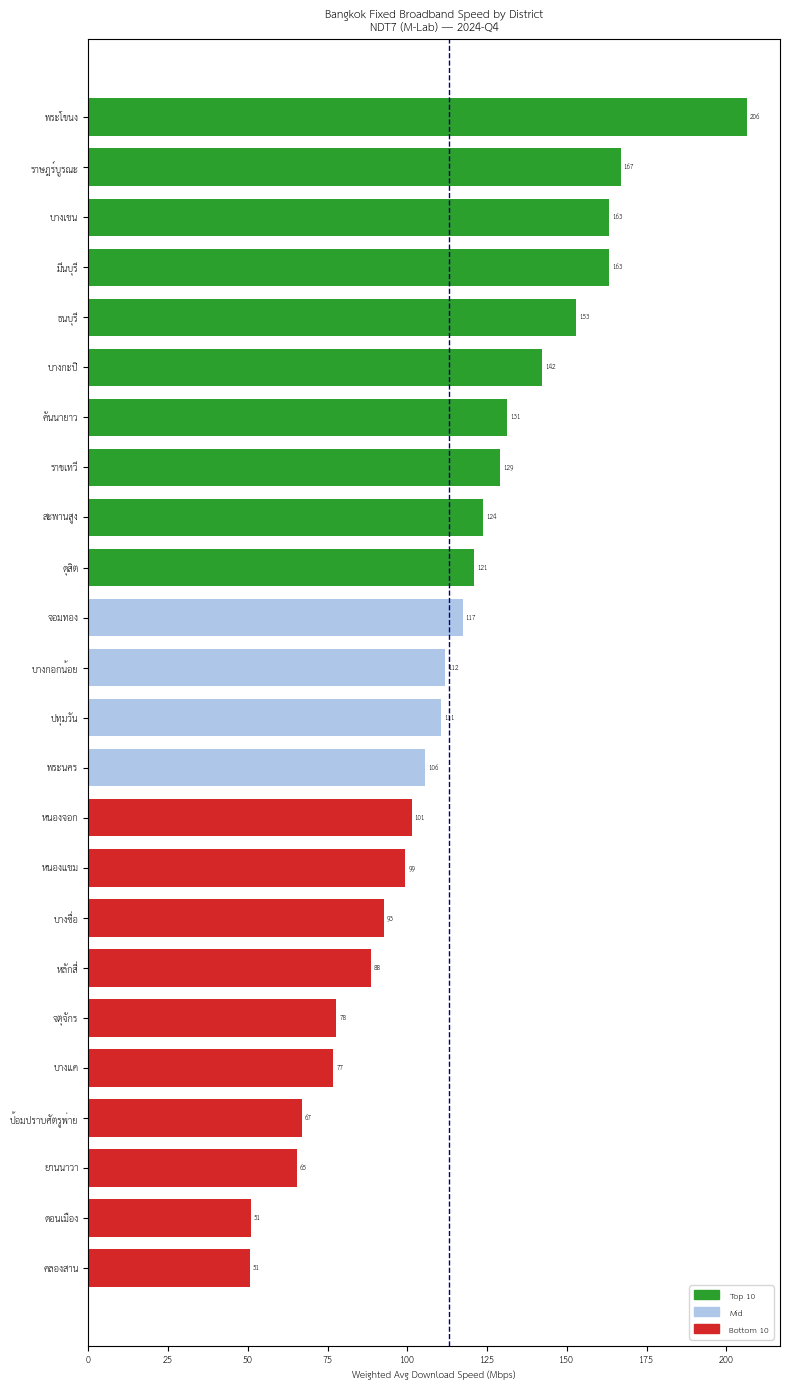

Saved: outputs/ndt7\bkk_district_ndt7_ranking_2024-Q4.png


In [32]:
df_plot = district_stats.sort_values(METRIC_MBPS, ascending=True)
labels  = df_plot['name_th'].tolist()
values  = df_plot[METRIC_MBPS].tolist()

# Color: top 10 green, bottom 10 red, rest grey
n = len(df_plot)
colors = ['#d62728' if i < 10 else ('#2ca02c' if i >= n - 10 else '#aec7e8') for i in range(n)]

fig, ax = plt.subplots(figsize=(8, 14))
bars = ax.barh(labels, values, color=colors, edgecolor='none', height=0.75)

for bar, val in zip(bars, values):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f'{val:.0f}', va='center', ha='left', fontsize=7)

ax.set_xlabel('Weighted Avg Download Speed (Mbps)', fontsize=10)
ax.set_title(f'Bangkok Fixed Broadband Speed by District\nNDT7 (M-Lab) — {QUARTER_LABEL}', fontsize=12)
ax.axvline(district_stats[METRIC_MBPS].mean(), color='navy', linestyle='--', linewidth=1, label='BKK mean')
ax.legend(fontsize=9)

patches = [
    mpatches.Patch(color='#2ca02c', label='Top 10'),
    mpatches.Patch(color='#aec7e8', label='Mid'),
    mpatches.Patch(color='#d62728', label='Bottom 10'),
]
ax.legend(handles=patches, fontsize=9, loc='lower right')

plt.tight_layout()
os.makedirs(OUTPUT_DIR, exist_ok=True)
out = os.path.join(OUTPUT_DIR, f'bkk_district_ndt7_ranking_{QUARTER_LABEL}.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

### Choropleth Map

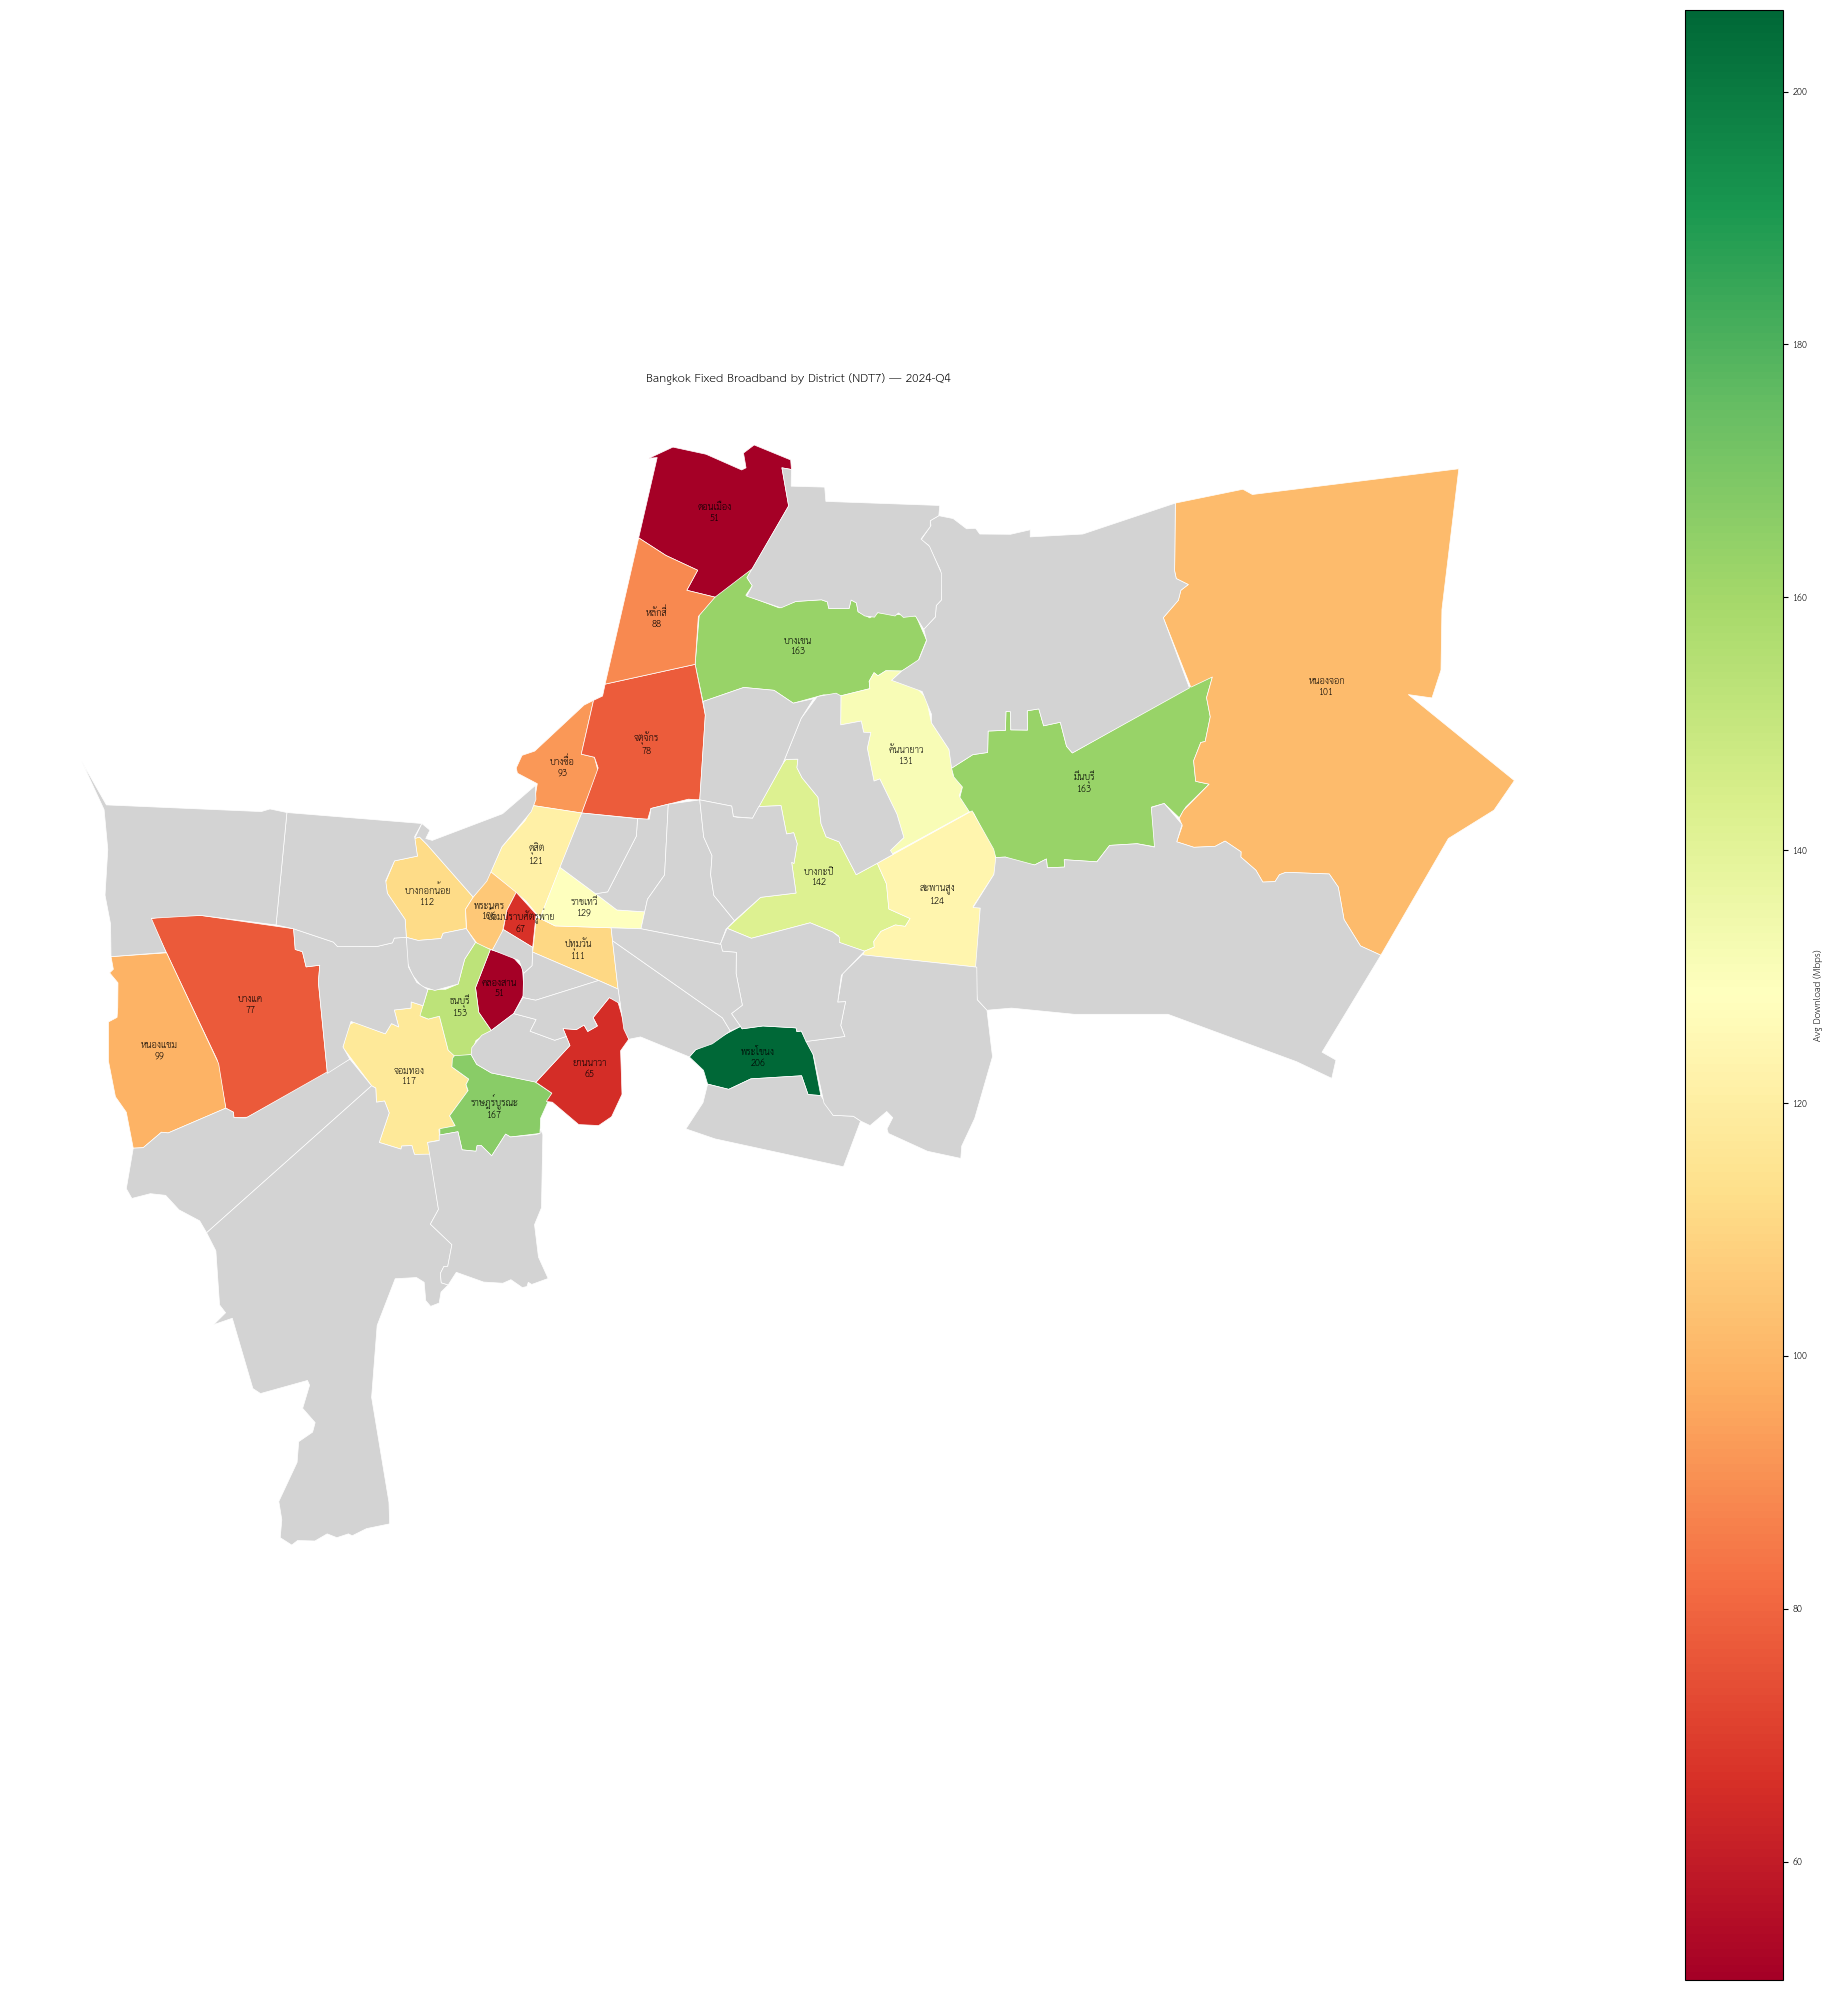

Saved: outputs/ndt7\bkk_district_ndt7_map_2024-Q4.png


In [33]:
district_geo = bkk_gdf.merge(district_stats, on=['name_en', 'name_th'], how='left')

fig, ax = plt.subplots(1, figsize=(20, 20))
district_geo.plot(
    column=METRIC_MBPS,
    ax=ax,
    cmap='RdYlGn',
    legend=True,
    legend_kwds={'label': 'Avg Download (Mbps)', 'orientation': 'vertical'},
    edgecolor='white',
    linewidth=0.5,
    missing_kwds={'color': 'lightgrey', 'label': 'No data'},
)

# Label each district with Thai name + speed
for _, row in district_geo.iterrows():
    if pd.notna(row[METRIC_MBPS]):
        c = row.geometry.centroid
        ax.annotate(
            f"{row['name_th']}\n{row[METRIC_MBPS]:.0f}",
            xy=(c.x, c.y), ha='center', va='center',
            fontsize=10, color='black',
        )

ax.set_title(f'Bangkok Fixed Broadband by District (NDT7) — {QUARTER_LABEL}', fontsize=13)
ax.set_axis_off()

plt.tight_layout()
out_map = os.path.join(OUTPUT_DIR, f'bkk_district_ndt7_map_{QUARTER_LABEL}.png')
plt.savefig(out_map, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {out_map}')

### Export District Stats CSV

In [34]:
os.makedirs(OUTPUT_DIR, exist_ok=True)
out_csv = os.path.join(OUTPUT_DIR, f'bkk_district_ndt7_{QUARTER_LABEL}.csv')
district_stats.to_csv(out_csv, index=False)
print(f'Saved: {out_csv}')
district_stats

Saved: outputs/ndt7\bkk_district_ndt7_2024-Q4.csv


,name_en,name_th,avg_d_mbps,total_tests,n_tiles,rank
0,Prakanong,พระโขนง,206.446619,452.0,1.0,1
1,RatBurana,ราษฎร์บูรณะ,166.817602,8721.0,2.0,2
2,BangKhen,บางเขน,163.208454,22422.0,2.0,3
3,MinBuri,มีนบุรี,163.164747,11909.0,2.0,4
4,ThonBuri,ธนบุรี,152.807893,62604.0,1.0,5
5,BangKapi,บางกะปิ,142.133099,12537.0,1.0,6
6,KhanNaYao,คันนายาว,131.193668,3009.0,1.0,7
7,Ratchathewi,ราชเทวี,129.053994,61208.0,1.0,8
8,SaphanSung,สะพานสูง,123.637842,853.0,1.0,9
9,Dusit,ดุสิต,120.765677,94592.0,2.0,10
